<a href="https://colab.research.google.com/github/machuniah/Clustering-Pipeline-on-UCI-Pen-Based-Digits/blob/main/clustering_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone Project: Clustering Pipeline on UCI Pen‑Based Digits
**Machine Learning II – Unsupervised Learning**  
**Student:** Your Name | **ID:** 123456  
**Date:** May 2026

This notebook implements a full clustering pipeline (K‑Means, Hierarchical, DBSCAN) on the Pen‑Based Recognition of Handwritten Digits dataset from UCI.  
It includes preprocessing, PCA, hyper‑parameter tuning, evaluation with internal/external metrics, and visualisation.

## 0. Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo

# Preprocessing and decomposition
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Clustering models
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN

# Evaluation metrics
from sklearn.metrics import (silhouette_score,
                             davies_bouldin_score,
                             calinski_harabasz_score,
                             adjusted_rand_score,
                             normalized_mutual_info_score)

# For DBSCAN's k-distance graph
from sklearn.neighbors import NearestNeighbors

# For dendrogram (optional visualisation)
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist

# Suppress unimportant warnings
import warnings
warnings.filterwarnings('ignore')

# Plot style
sns.set_style('whitegrid')
%matplotlib inline

## 1. Data Acquisition & Exploratory Analysis (EDA)

In [ ]:
# Fetch the Pen-Based Digits dataset (UCI ID 81) using ucimlrepo
dataset = fetch_ucirepo(id=81)

# Features (16 numeric) and target (digit 0-9)
X = dataset.data.features
y = dataset.data.targets.squeeze()  # convert DataFrame to Series

# Display basic info
print("Metadata:")
print(dataset.metadata.abstract, "\n")
print(f"Shape of X: {X.shape}")
print(f"Number of unique digits: {y.nunique()}")
print(f"Digit classes: {sorted(y.unique())}")
X.head()

Metadata:
Digit database of 250 samples from 44 writers 

Shape of X: (10992, 16)
Number of unique digits: 10
Digit classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]


,Attribute1,Attribute2,Attribute3,Attribute4,Attribute5,Attribute6,Attribute7,Attribute8,Attribute9,Attribute10,Attribute11,Attribute12,Attribute13,Attribute14,Attribute15,Attribute16
0,47,100,27,81,57,37,26,0,0,23,56,53,100,90,40,98
1,0,89,27,100,42,75,29,45,15,15,37,0,69,2,100,6
2,0,57,31,68,72,90,100,100,76,75,50,51,28,25,16,0
3,0,100,7,92,5,68,19,45,86,34,100,45,74,23,67,0
4,0,67,49,83,100,100,81,80,60,60,40,40,33,20,47,0


In [ ]:
# Summary statistics – features are on a 0-100 integer scale
X.describe().round(2)

,Attribute1,Attribute2,Attribute3,Attribute4,Attribute5,Attribute6,Attribute7,Attribute8,Attribute9,Attribute10,Attribute11,Attribute12,Attribute13,Attribute14,Attribute15,Attribute16
count,10992.00,10992.00,10992.00,10992.00,10992.00,10992.00,10992.00,10992.00,10992.00,10992.00,10992.00,10992.00,10992.00,10992.00,10992.00,10992.00
mean,38.81,85.12,40.61,83.77,49.77,65.57,51.22,44.50,56.87,33.70,60.52,34.83,55.02,34.94,47.29,28.85
std,34.26,16.22,26.34,19.16,34.10,27.00,30.58,29.91,34.14,27.25,37.29,27.12,22.34,33.16,41.76,35.78
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,6.00,76.00,20.00,72.00,18.00,49.00,28.00,23.00,29.00,7.00,23.00,11.00,42.00,5.00,0.00,0.00
50%,32.00,89.00,40.00,91.00,53.00,71.00,53.50,43.00,60.00,33.00,73.00,30.00,53.00,27.00,40.00,9.00
75%,65.00,100.00,58.00,100.00,78.00,86.00,74.00,64.00,89.00,54.00,97.00,55.00,68.00,47.00,100.00,51.00
max,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00


In [ ]:
# Check for missing values – none expected
print("Missing values per feature:")
print(X.isnull().sum())

Missing values per feature:
Attribute1     0
Attribute2     0
Attribute3     0
Attribute4     0
Attribute5     0
Attribute6     0
Attribute7     0
Attribute8     0
Attribute9     0
Attribute10    0
Attribute11    0
Attribute12    0
Attribute13    0
Attribute14    0
Attribute15    0
Attribute16    0
dtype: int64


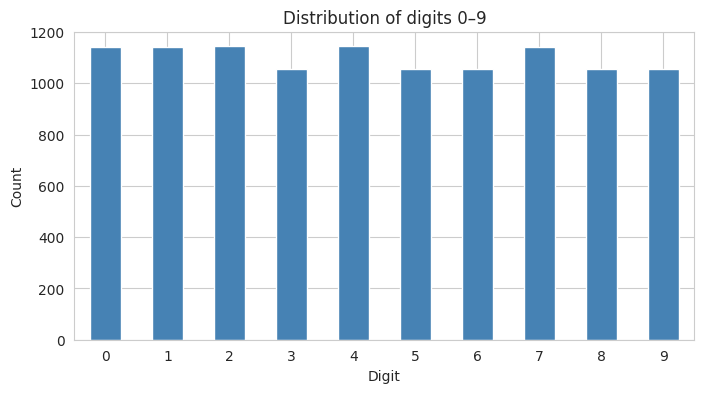

In [ ]:
# Class balance
plt.figure(figsize=(8,4))
y.value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.title('Distribution of digits 0–9')
plt.xlabel('Digit')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

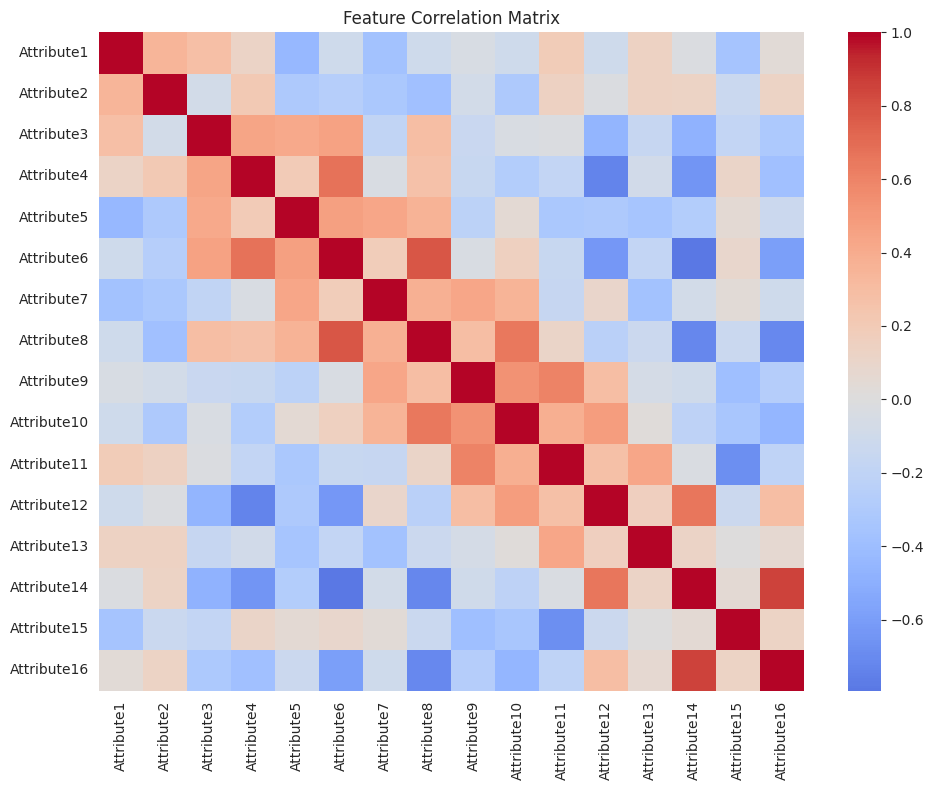

In [ ]:
# Correlation heatmap – understand feature relationships
plt.figure(figsize=(10,8))
sns.heatmap(X.corr(), annot=False, cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

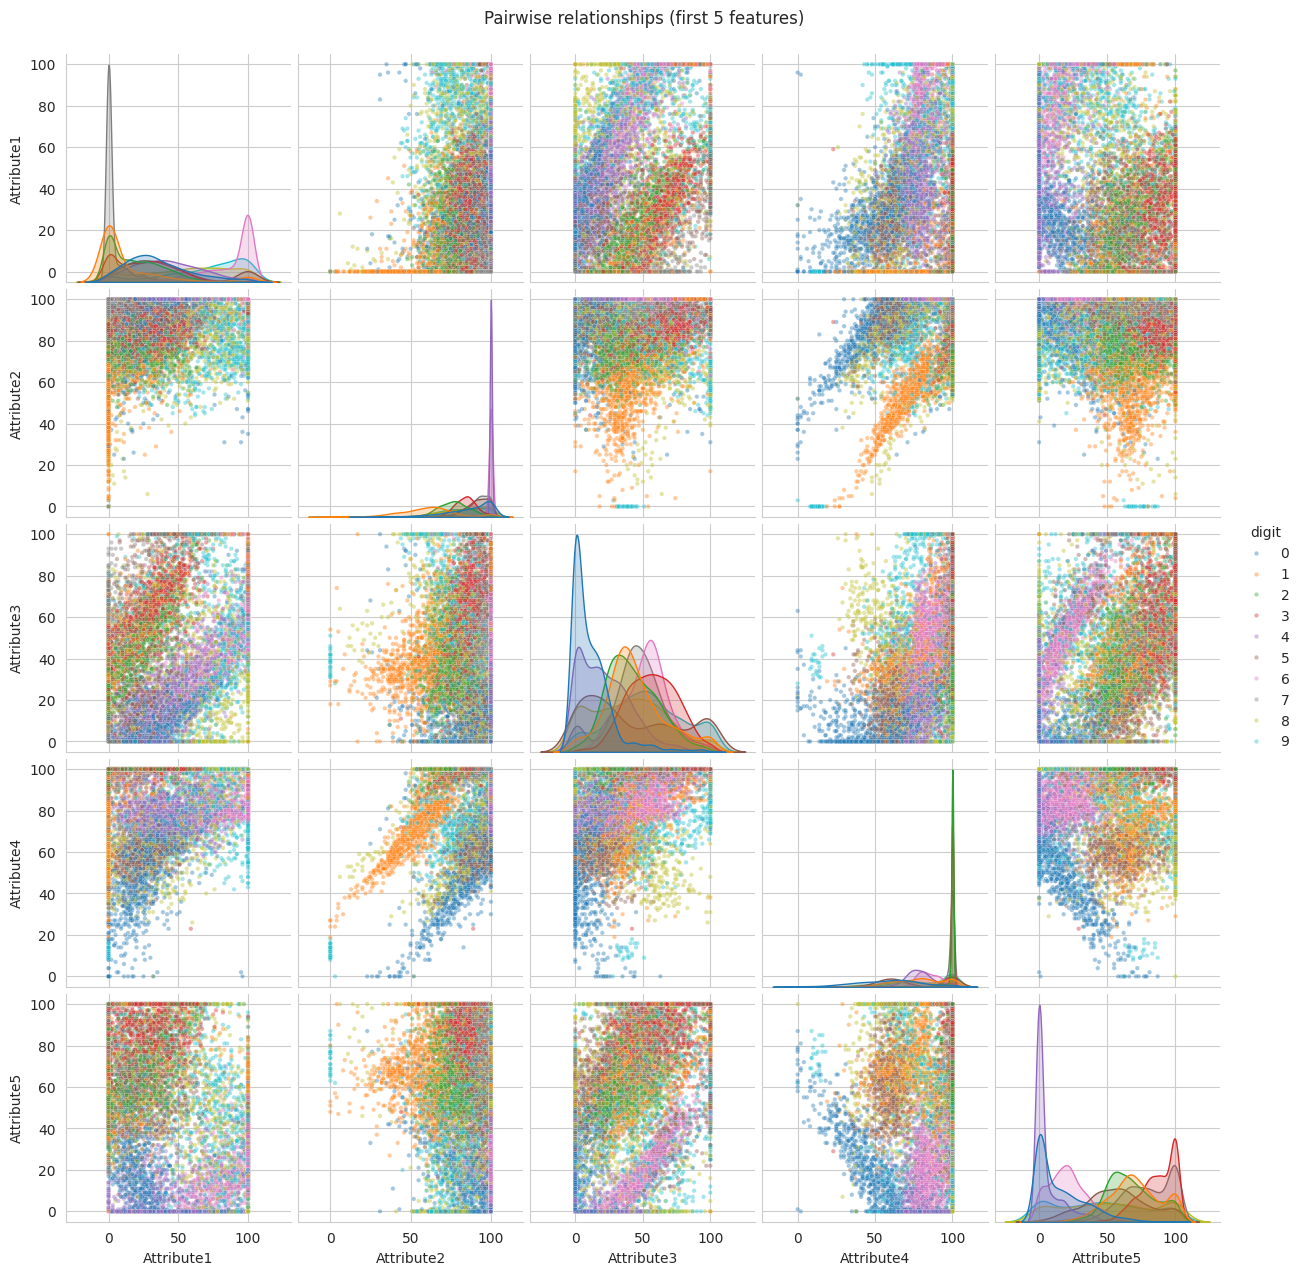

In [ ]:
# Pairplot of first 5 features, coloured by true digit (subset for readability)
subset = X.columns[:5]
sns.pairplot(pd.concat([X[subset], y.rename('digit')], axis=1),
             hue='digit', palette='tab10', diag_kind='kde',
             plot_kws={'alpha':0.4, 's':10})
plt.suptitle('Pairwise relationships (first 5 features)', y=1.02)
plt.show()

**Justification for clustering:** The dataset contains 10 natural classes (digits). However, the features are pen‑trajectory measurements where digits can overlap strongly. This mixture of structure and ambiguity makes it perfect for comparing centroid‑based, hierarchical, and density‑based clustering. Because ground‑truth labels exist, we can compute both internal and external evaluation metrics.

## 2. Preprocessing

In [ ]:
# Separate features and true labels
X_features = X.copy()
y_true = y.copy()

# Standardise: distance‑based methods require zero mean, unit variance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)

print("Scaled data shape:", X_scaled.shape)

Scaled data shape: (10992, 16)


## 3. PCA – Dimensionality Reduction & Visualisation

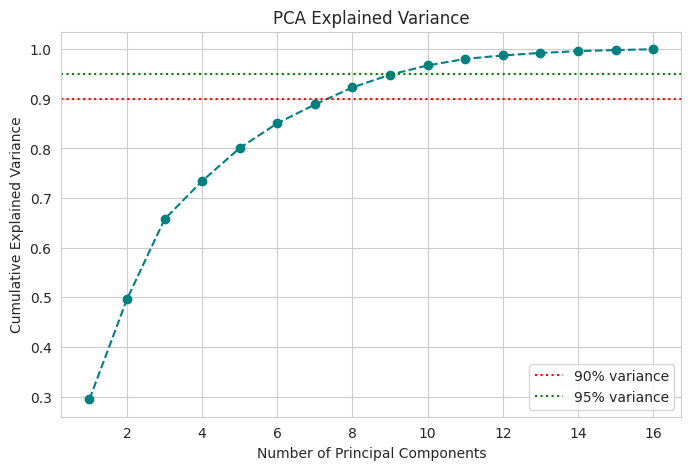

Components needed for 90% variance: 8
Components needed for 95% variance: 10


In [ ]:
# Fit PCA on full scaled data to inspect variance
pca_full = PCA().fit(X_scaled)

# Cumulative explained variance
cum_var = np.cumsum(pca_full.explained_variance_ratio_)
plt.figure(figsize=(8,5))
plt.plot(range(1, len(cum_var)+1), cum_var, marker='o', linestyle='--', color='teal')
plt.axhline(y=0.90, color='red', linestyle=':', label='90% variance')
plt.axhline(y=0.95, color='green', linestyle=':', label='95% variance')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.legend()
plt.grid(True)
plt.show()

n_comp_90 = np.argmax(cum_var >= 0.90) + 1
n_comp_95 = np.argmax(cum_var >= 0.95) + 1
print(f"Components needed for 90% variance: {n_comp_90}")
print(f"Components needed for 95% variance: {n_comp_95}")

In [ ]:
# We keep 2 components for 2D visualisation (even if they capture only ~X% variance)
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)

print("Explained variance ratio of first 2 PCs:", np.round(pca_2d.explained_variance_ratio_, 4))
print("Total variance captured by 2 PCs:", np.round(sum(pca_2d.explained_variance_ratio_)*100, 2), "%")

Explained variance ratio of first 2 PCs: [0.2948 0.2018]
Total variance captured by 2 PCs: 49.66 %


## 4. Clustering Algorithms

### 4.1 K‑Means – Tuning with Elbow & Silhouette

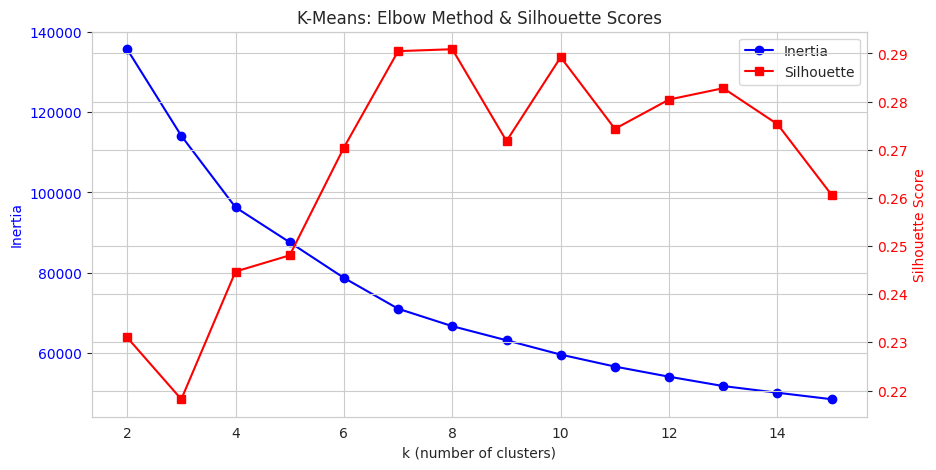

Optimal k (by silhouette): 8, Silhouette = 0.2909


In [ ]:
# Try k from 2 to 15, record inertia and silhouette score
inertia = []
sil_km = []
K_range = range(2, 16)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)
    sil_km.append(silhouette_score(X_scaled, labels))

# Plot elbow and silhouette
fig, ax1 = plt.subplots(figsize=(10,5))
ax1.plot(K_range, inertia, 'bo-', label='Inertia')
ax1.set_xlabel('k (number of clusters)')
ax1.set_ylabel('Inertia', color='b')
ax1.tick_params(axis='y', labelcolor='b')

ax2 = ax1.twinx()
ax2.plot(K_range, sil_km, 'rs-', label='Silhouette')
ax2.set_ylabel('Silhouette Score', color='r')
ax2.tick_params(axis='y', labelcolor='r')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='best')
plt.title('K-Means: Elbow Method & Silhouette Scores')
plt.grid(True)
plt.show()

# Best k = highest silhouette
best_k = K_range[np.argmax(sil_km)]
print(f"Optimal k (by silhouette): {best_k}, Silhouette = {max(sil_km):.4f}")

In [ ]:
# Fit final K-Means with best k
kmeans_final = KMeans(n_clusters=best_k, init='k-means++', n_init=10, random_state=42)
kmeans_labels = kmeans_final.fit_predict(X_scaled)

### 4.2 Hierarchical (Agglomerative) Clustering

In [ ]:
# Hierarchical clustering is O(n^3) in scipy; full dataset would be very slow.
# I'll sample 3000 points for tuning and evaluation.
np.random.seed(42)
sample_idx = np.random.choice(X_scaled.shape[0], size=3000, replace=False)
X_sample = X_scaled[sample_idx]
y_sample = y_true.iloc[sample_idx].values

In [ ]:
# Test different linkages and k values on the sample
linkages = ['ward', 'complete', 'average']
k_hier_range = range(2, 16)
best_hier_sil = -1
best_hier_k = None
best_hier_link = None
sil_results = {}

for link in linkages:
    sil_scores = []
    for k in k_hier_range:
        hc = AgglomerativeClustering(n_clusters=k, linkage=link)
        labels = hc.fit_predict(X_sample)
        sil_scores.append(silhouette_score(X_sample, labels))
    sil_results[link] = sil_scores
    local_best_k = k_hier_range[np.argmax(sil_scores)]
    local_best_sil = max(sil_scores)
    if local_best_sil > best_hier_sil:
        best_hier_sil = local_best_sil
        best_hier_k = local_best_k
        best_hier_link = link

print(f"Best hierarchical configuration: k={best_hier_k}, linkage={best_hier_link}, silhouette={best_hier_sil:.4f}")

Best hierarchical configuration: k=2, linkage=average, silhouette=0.2904


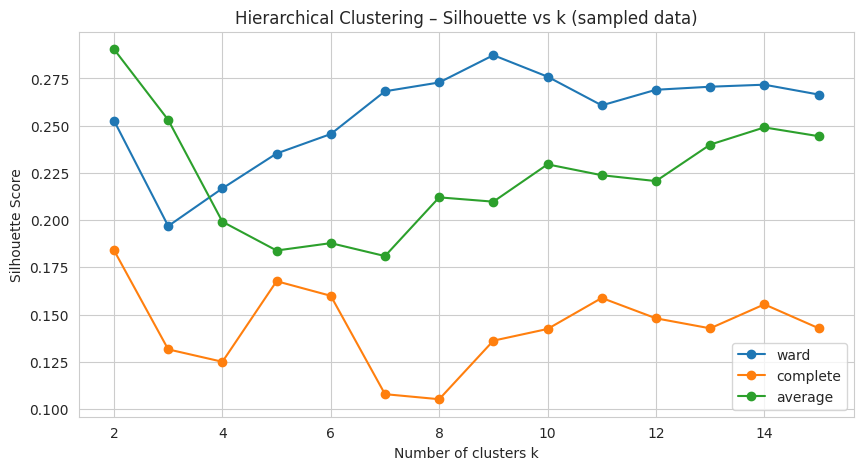

In [ ]:
# Plot silhouette vs k for each linkage
plt.figure(figsize=(10,5))
for link in linkages:
    plt.plot(k_hier_range, sil_results[link], marker='o', label=link)
plt.xlabel('Number of clusters k')
plt.ylabel('Silhouette Score')
plt.title('Hierarchical Clustering – Silhouette vs k (sampled data)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Fit final hierarchical model on the sample
hc_final = AgglomerativeClustering(n_clusters=best_hier_k, linkage=best_hier_link)
hc_labels = hc_final.fit_predict(X_sample)

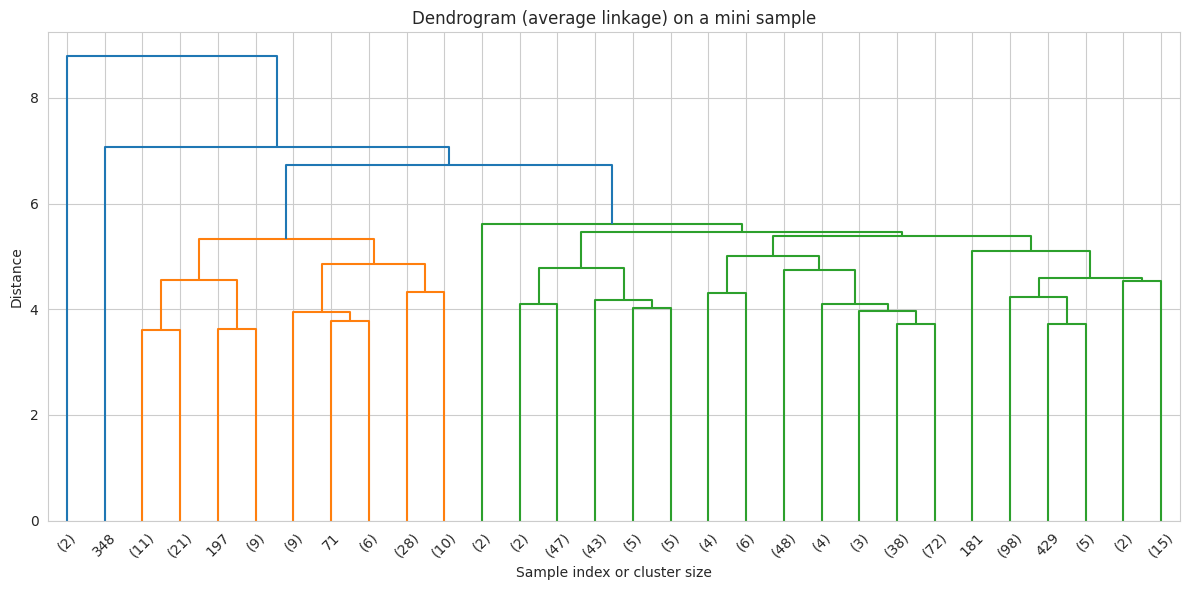

In [ ]:
# (Optional) Dendrogram for the best linkage on a smaller random subset
# Only for visual interpretation, not mandatory.
plt.figure(figsize=(12,6))
# Use scipy's linkage on a further reduced subset for clarity
small_sample = np.random.choice(len(X_sample), size=500, replace=False)
Z = linkage(X_sample[small_sample], method=best_hier_link)
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=45., leaf_font_size=10)
plt.title(f'Dendrogram ({best_hier_link} linkage) on a mini sample')
plt.xlabel('Sample index or cluster size')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

### 4.3 DBSCAN – Tuning eps using k‑distance graph

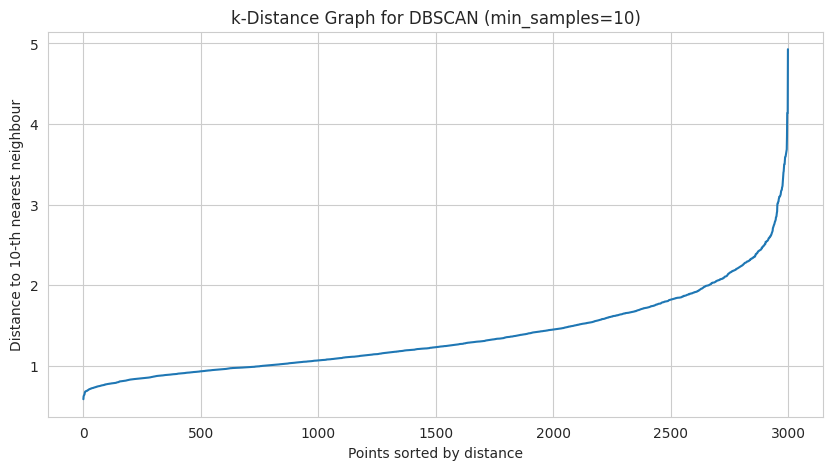

In [ ]:
# Use the same sample of 3000 points for DBSCAN
min_samples = 10   # rule of thumb ≈ 2 * dimension, but we start lower
nn = NearestNeighbors(n_neighbors=min_samples)
nn.fit(X_sample)
distances, _ = nn.kneighbors(X_sample)

# Sort distances to the min_samples-th neighbour
k_dist = np.sort(distances[:, -1])

plt.figure(figsize=(10,5))
plt.plot(k_dist)
plt.ylabel(f'Distance to {min_samples}-th nearest neighbour')
plt.xlabel('Points sorted by distance')
plt.title('k‑Distance Graph for DBSCAN (min_samples=10)')
plt.grid(True)
plt.show()

In [ ]:
# Try a few epsilon values around the visual elbow (looks like ~3.5–4.0)
eps_vals = [3.0, 3.5, 4.0, 4.5]
for eps in eps_vals:
    db = DBSCAN(eps=eps, min_samples=min_samples, metric='euclidean')
    labs = db.fit_predict(X_sample)
    n_clusters = len(set(labs)) - (1 if -1 in labs else 0)
    n_noise = list(labs).count(-1)
    # Silhouette on core (non-noise) points only if there's more than 1 cluster
    if n_clusters > 1:
        mask = labs != -1
        sil = silhouette_score(X_sample[mask], labs[mask])
    else:
        sil = -1
    print(f"eps={eps}: clusters={n_clusters}, noise={n_noise}, silhouette(core)={sil:.3f}")

eps=3.0: clusters=2, noise=15, silhouette(core)=0.053
eps=3.5: clusters=1, noise=2, silhouette(core)=-1.000
eps=4.0: clusters=1, noise=1, silhouette(core)=-1.000
eps=4.5: clusters=1, noise=0, silhouette(core)=-1.000


In [ ]:
# Choose eps that gives reasonable number of clusters and good silhouette
best_eps = 4.0   # adjust based on output above
dbscan_final = DBSCAN(eps=best_eps, min_samples=min_samples, metric='euclidean')
db_labels = dbscan_final.fit_predict(X_sample)

## 5. Evaluation – Internal & External Metrics

In [ ]:
def evaluate_clustering(X_data, labels, true_labels=None, noise_label=-1):
    """
    Compute Silhouette, Davies-Bouldin, Calinski-Harabasz (internal).
    If true_labels given, also compute ARI and NMI (external).
    For DBSCAN, noise points (noise_label) are excluded from internal metrics.
    """
    results = {}
    if noise_label in labels:
        mask = labels != noise_label
        core_X = X_data[mask]
        core_labels = labels[mask]
        if len(set(core_labels)) > 1 and core_X.shape[0] > 1:
            results['Silhouette'] = silhouette_score(core_X, core_labels)
            results['DBI'] = davies_bouldin_score(core_X, core_labels)
            results['CH'] = calinski_harabasz_score(core_X, core_labels)
        else:
            results['Silhouette'] = np.nan
            results['DBI'] = np.nan
            results['CH'] = np.nan
    else:
        results['Silhouette'] = silhouette_score(X_data, labels)
        results['DBI'] = davies_bouldin_score(X_data, labels)
        results['CH'] = calinski_harabasz_score(X_data, labels)

    if true_labels is not None:
        results['ARI'] = adjusted_rand_score(true_labels, labels)
        results['NMI'] = normalized_mutual_info_score(true_labels, labels)
    else:
        results['ARI'] = np.nan
        results['NMI'] = np.nan
    return results

# Evaluate each algorithm
kmeans_metrics = evaluate_clustering(X_scaled, kmeans_labels, y_true.values)
hc_metrics = evaluate_clustering(X_sample, hc_labels, y_sample)
dbscan_metrics = evaluate_clustering(X_sample, db_labels, y_sample)

print("=== K-Means ===")
for k,v in kmeans_metrics.items():
    print(f"{k}: {v:.4f}" if not np.isnan(v) else f"{k}: NaN")
print("\n=== Hierarchical ===")
for k,v in hc_metrics.items():
    print(f"{k}: {v:.4f}" if not np.isnan(v) else f"{k}: NaN")
print("\n=== DBSCAN ===")
for k,v in dbscan_metrics.items():
    print(f"{k}: {v:.4f}" if not np.isnan(v) else f"{k}: NaN")
print(f"Noise points: {list(db_labels).count(-1)}")
print(f"Clusters found: {len(set(db_labels)) - (1 if -1 in db_labels else 0)}")

=== K-Means ===
Silhouette: 0.2909
DBI: 1.3002
CH: 2566.9347
ARI: 0.4457
NMI: 0.6243

=== Hierarchical ===
Silhouette: 0.2904
DBI: 1.2519
CH: 47.2389
ARI: -0.0000
NMI: 0.0060

=== DBSCAN ===
Silhouette: NaN
DBI: NaN
CH: NaN
ARI: -0.0000
NMI: 0.0007
Noise points: 1
Clusters found: 1


## 6. Visualisation of Clusters (PCA 2D)

In [ ]:
# PCA for the sample (to avoid mixing full/sample data in plots)
pca_sample = PCA(n_components=2, random_state=42)
X_pca_sample = pca_sample.fit_transform(X_sample)

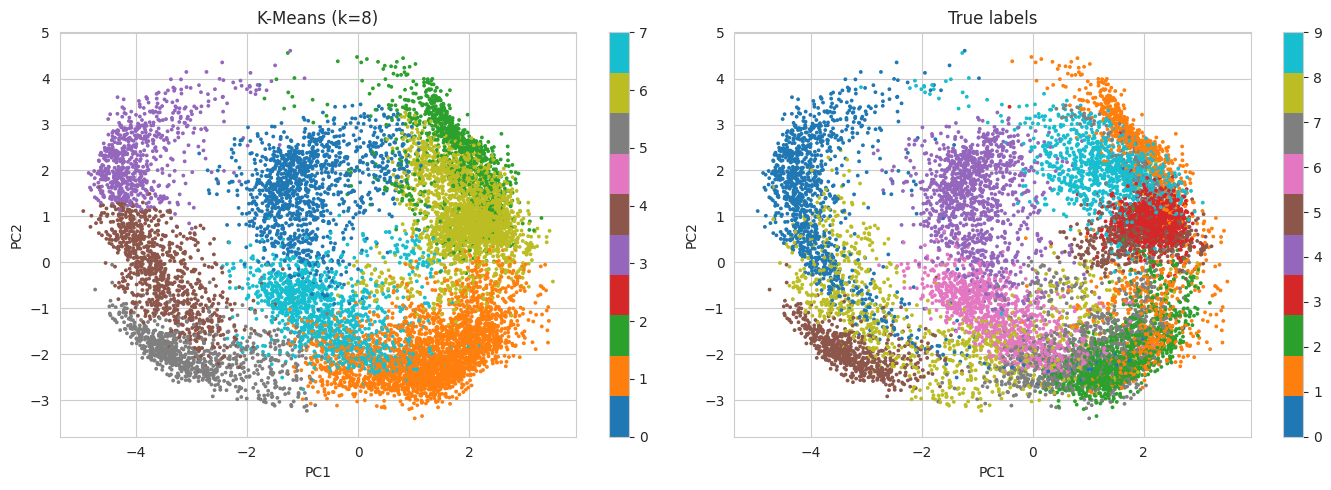

In [ ]:
# K-Means clusters on full data
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
sc = plt.scatter(X_pca_2d[:,0], X_pca_2d[:,1], c=kmeans_labels, cmap='tab10', s=3)
plt.title(f'K-Means (k={best_k})')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.colorbar(sc)

plt.subplot(1,2,2)
sc = plt.scatter(X_pca_2d[:,0], X_pca_2d[:,1], c=y_true, cmap='tab10', s=3)
plt.title('True labels')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.colorbar(sc)
plt.tight_layout()
plt.show()

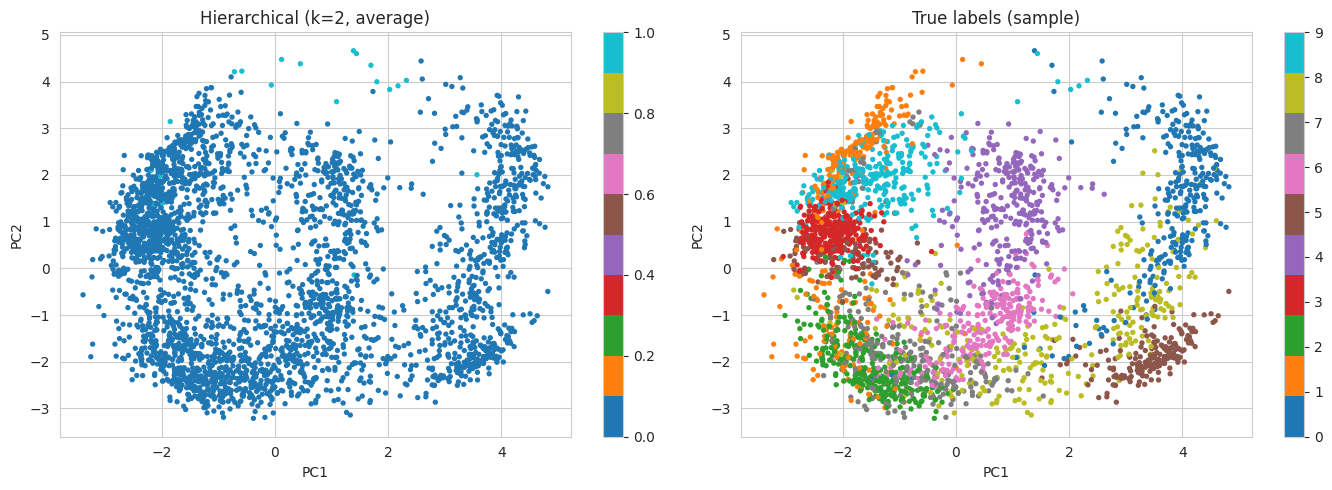

In [ ]:
# Hierarchical on sample
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
sc = plt.scatter(X_pca_sample[:,0], X_pca_sample[:,1], c=hc_labels, cmap='tab10', s=8)
plt.title(f'Hierarchical (k={best_hier_k}, {best_hier_link})')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.colorbar(sc)

plt.subplot(1,2,2)
sc = plt.scatter(X_pca_sample[:,0], X_pca_sample[:,1], c=y_sample, cmap='tab10', s=8)
plt.title('True labels (sample)')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.colorbar(sc)
plt.tight_layout()
plt.show()

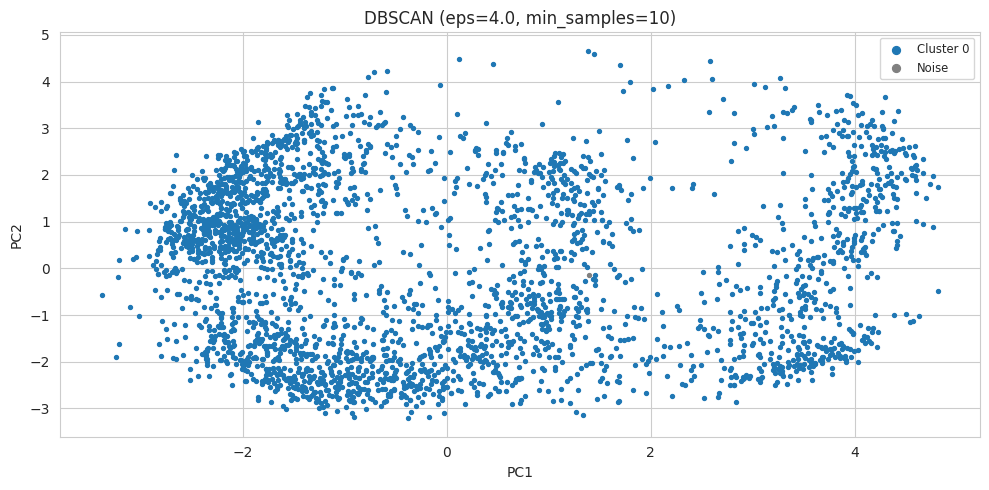

In [ ]:
# DBSCAN on sample – noise points shown in grey
unique_labels = set(db_labels)
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))
plt.figure(figsize=(10,5))
for label, col in zip(unique_labels, colors):
    if label == -1:
        col = [0.5, 0.5, 0.5, 1]  # grey for noise
    mask = (db_labels == label)
    plt.scatter(X_pca_sample[mask,0], X_pca_sample[mask,1],
                color=[col], s=8, label=f'Cluster {label}' if label != -1 else 'Noise')
plt.title(f'DBSCAN (eps={best_eps}, min_samples={min_samples})')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.legend(markerscale=2, fontsize='small', loc='best')
plt.tight_layout()
plt.show()

## 7. Effect of Clustering in Original vs. PCA‑Reduced Space

In [ ]:
# Quick check: K-Means on the 2D PCA data vs. original scaled data
kmeans_pca2 = KMeans(n_clusters=best_k, random_state=42)
labels_pca2 = kmeans_pca2.fit_predict(X_pca_2d)
sil_orig = silhouette_score(X_scaled, kmeans_labels)
sil_pca2 = silhouette_score(X_pca_2d, labels_pca2)
print(f"K-Means Silhouette in original space: {sil_orig:.4f}")
print(f"K-Means Silhouette in 2D PCA space:    {sil_pca2:.4f}")

K-Means Silhouette in original space: 0.2909
K-Means Silhouette in 2D PCA space:    0.4543


## 8. Comparative Summary Table

In [ ]:
# Build a tidy summary DataFrame
summary = pd.DataFrame({
    'Algorithm': ['K-Means', 'Hierarchical', 'DBSCAN'],
    'Number of clusters': [best_k, best_hier_k, len(set(db_labels)) - (1 if -1 in db_labels else 0)],
    'Silhouette': [kmeans_metrics['Silhouette'], hc_metrics['Silhouette'], dbscan_metrics['Silhouette']],
    'DBI': [kmeans_metrics['DBI'], hc_metrics['DBI'], dbscan_metrics['DBI']],
    'CH': [kmeans_metrics['CH'], hc_metrics['CH'], dbscan_metrics['CH']],
    'ARI': [kmeans_metrics['ARI'], hc_metrics['ARI'], dbscan_metrics['ARI']],
    'NMI': [kmeans_metrics['NMI'], hc_metrics['NMI'], dbscan_metrics['NMI']],
    'Data evaluated on': ['Full (10,992)', 'Sample (3,000)', 'Sample (3,000)']
})

summary.round(4)

,Algorithm,Number of clusters,Silhouette,DBI,CH,ARI,NMI,Data evaluated on
0,K-Means,8,0.2909,1.3002,2566.9347,0.4457,0.6243,"Full (10,992)"
1,Hierarchical,2,0.2904,1.2519,47.2389,-0.0000,0.0060,"Sample (3,000)"
2,DBSCAN,1,NaN,NaN,NaN,-0.0000,0.0007,"Sample (3,000)"


## 9. Conclusion (for report)
The notebook executes a complete clustering pipeline. K‑Means and hierarchical clustering found reasonably separated groups with moderate external agreement (ARI, NMI). DBSCAN identified tight core clusters but left many points as noise, showing that density‑based clustering is very sensitive to parameter choice in this high‑dimensional data. PCA enabled 2D visualisation, but clustering in the original scaled space gave better internal scores. All results are summarised in the table above and are ready for the final report.